# Actividad 4. Algoritmos de aprendizaje no supervisado con PySpark

### Nombre: Juan Paulo Pérez Tejada Ladrón de Guevara
### Matrícula: A01797972

Enlace al archivo: [Colab](https://colab.research.google.com/drive/12i2_vAf_8YmCNFkU0rN18uh4kihQNBVP?usp=sharing)

## Introducción

El aprendizaje no supervisado agrupa algoritmos que buscan patrones en datos no etiquetados. A diferencia del aprendizaje supervisado, no parte de una variable objetivo: su propósito es descubrir estructura latente en los datos. Entre los algoritmos representativos se encuentran:

- **Clustering** (K-Means, DBSCAN): agrupa puntos de datos en función de su similitud, sin etiquetas previas.
- **Reducción de dimensionalidad** (PCA, t-SNE): proyecta los datos a un espacio de menor dimensión preservando su estructura relevante.
- **Modelos generativos** (GAN, VAE): aprenden la distribución subyacente de los datos para generar nuevas muestras similares.
- **Autoencoders**: comprimen los datos en una representación latente y los reconstruyen, capturando estructura sin supervisión.
- **Frequent pattern mining** (FPGrowth, PrefixSpan): descubre relaciones frecuentes entre variables mediante reglas de asociación.

MLlib, la biblioteca de machine learning de Apache Spark, implementa dos de estas categorías: frequent pattern mining y clustering.

### Frequent Pattern Mining

El frequent pattern mining pertenece al aprendizaje de reglas de asociación. Los algoritmos de este tipo buscan primero elementos frecuentes en el conjunto de datos y luego pares o conjuntos de elementos que aparecen juntos con regularidad. Las reglas siguen la estructura básica de antecedente (*si*) y consecuente (*entonces*). MLlib implementa dos funciones de este tipo: `FPGrowth` y `PrefixSpan`, útiles como procedimientos de preprocesamiento para motores de recomendación o para detectar patrones en corpus de texto.

### Clustering

El clustering es una técnica de agrupamiento para descubrir relaciones ocultas entre puntos de datos. Se aplica regularmente en segmentación de clientes, procesamiento de imágenes, filtrado de spam y detección de anomalías. En el proceso de clustering, cada punto se asigna al grupo cuyo centro le queda más próximo; los algoritmos optimizan iterativamente la posición de esos centros para minimizar la pérdida global.

MLlib ofrece varios algoritmos de clustering:

- **`KMeans`**: el más popular por su simplicidad y eficiencia. Crea centros aleatorios e itera sobre los puntos de datos buscando agrupar los similares y encontrar los centros óptimos. Siempre converge, aunque la calidad depende del número de clusters (*k*) y del número de iteraciones.
- **`BisectingKMeans`**: variante jerárquica divisiva de K-Means. Parte de un solo cluster y lo divide sucesivamente, lo que puede producir mejores resultados cuando la estructura de los datos es jerárquica.
- **`GaussianMixture`**: útil para identificar subgrupos dentro de grupos más amplios. Su limitación principal es el bajo desempeño en datos de alta dimensionalidad, donde le cuesta converger.
- **`LDA`** *(Latent Dirichlet Allocation)*: algoritmo estadístico general usado en procesamiento de lenguaje natural y biomedicina. Espera vectores de conteo de palabras, por lo que no es adecuado para datos geoespaciales o numéricos continuos como los de este ejercicio.
- **`PowerIterationClustering`**: opción escalable para clustering de vértices de un grafo a partir de similitudes por pares. Su limitación es que no implementa el patrón `Estimator`/`Transformer` de MLlib, por lo que no puede usarse dentro de un pipeline de Spark.

En este ejercicio se aplica `KMeans` para descubrir **perfiles de viaje** en los datos de taxis amarillos de NYC: combinaciones recurrentes de zona de origen, destino, hora y día que emergen de los datos sin categorías impuestas a priori. Los clusters resultantes pueden informar una **estratificación más razonada** en trabajos supervisados posteriores, en lugar de depender de particiones definidas manualmente.

#### Referencias

Polak, A. (2023). *Scaling machine learning with Spark*. O'Reilly Media. https://learning.oreilly.com/library/view/scaling-machine-learning/9781098106812/ch06.html#unsupervised_mac

## Inicialización y carga de datos

### Inicia ambiente

In [1]:
!apt-get update -qq
!apt-get install openjdk-11-jdk -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark
!pip install -q folium


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder     .appName("nyc_taxi_clustering")     .config("spark.sql.session.timeZone", "UTC")     .config("spark.driver.memory", "8g")     .config("spark.executor.memory", "8g")     .getOrCreate()

### Descarga datos de Kaggle

In [3]:
import kagglehub
file_path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")
print("Path to dataset files:", file_path)

Using Colab cache for faster access to the 'nyc-yellow-taxi-trip-data' dataset.
Path to dataset files: /kaggle/input/nyc-yellow-taxi-trip-data


### Definir esquema

In [4]:
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, IntegerType, TimestampType,
    FloatType, BooleanType, DoubleType
)

schema = StructType([
    StructField("VendorID",              IntegerType(),  True),
    StructField("tpep_pickup_datetime",  TimestampType(), True),
    StructField("tpep_dropoff_datetime", TimestampType(), True),
    StructField("passenger_count",       IntegerType(),  True),
    StructField("trip_distance",         FloatType(),    True),
    StructField("pickup_longitude",      DoubleType(),   True),
    StructField("pickup_latitude",       DoubleType(),   True),
    StructField("RateCodeID",            IntegerType(),  True),
    StructField("store_and_fwd_flag",    BooleanType(),  True),
    StructField("dropoff_longitude",     DoubleType(),   True),
    StructField("dropoff_latitude",      DoubleType(),   True),
    StructField("payment_type",          IntegerType(),  True),
    StructField("fare_amount",           FloatType(),    True),
    StructField("extra",                 FloatType(),    True),
    StructField("mta_tax",              FloatType(),    True),
    StructField("tip_amount",            FloatType(),    True),
    StructField("tolls_amount",          FloatType(),    True),
    StructField("improvement_surcharge", FloatType(),    True),
    StructField("total_amount",          FloatType(),    True),
])

df = spark.read.csv(
    file_path + "/*.csv",
    header=True,
    schema=schema,
    timestampFormat="yyyy-MM-dd HH:mm:ss"
)

## Selección y limpieza de datos

Se conservan únicamente las variables geoespaciales y temporales de cada viaje. Las variables de tarifa se excluyen porque no aportan información sobre el patrón de movilidad: dependen del tiempo y la distancia, no al revés.

In [5]:
df = df.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
)

# Filtrado geográfico: bounding box de NYC (elimina (0,0) y registros fuera del área)
df = df.filter(
    F.col("pickup_latitude").between(40.5, 41.0) &
    F.col("pickup_longitude").between(-74.3, -73.7)
)

df = df.cache()
n_limpio = df.count()
print(f"Filas tras limpieza: {n_limpio:,}")

Filas tras limpieza: 46,468,938


## Creación de variables

Se calculan la distancia haversine entre origen y destino, la duración del viaje (para uso descriptivo, no como target), y las variables temporales que entrarán al modelo.

In [6]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Distancia haversine entre dos puntos geográficos (metros)."""
    R = 6_371_000
    phi1    = F.radians(lat1);  phi2 = F.radians(lat2)
    dphi    = F.radians(lat2 - lat1)
    dlambda = F.radians(lon2 - lon1)
    a = (F.pow(F.sin(dphi / 2), 2)
         + F.cos(phi1) * F.cos(phi2) * F.pow(F.sin(dlambda / 2), 2))
    c = 2 * F.atan2(F.sqrt(a), F.sqrt(1 - a))
    return F.lit(R) * c

df = df.withColumn(
    "trip_distance_m",
    haversine_m(
        F.col("pickup_latitude"),  F.col("pickup_longitude"),
        F.col("dropoff_latitude"), F.col("dropoff_longitude")
    )
).withColumn(
    "trip_duration_min",
    (F.col("tpep_dropoff_datetime").cast("long")
     - F.col("tpep_pickup_datetime").cast("long")) / 60
).withColumn("pickup_hour",    F.hour("tpep_pickup_datetime")
).withColumn("pickup_weekday", F.dayofweek("tpep_pickup_datetime"))

# Filtrar outliers
df = df.filter(
    (F.col("trip_duration_min") > 3)   & (F.col("trip_duration_min") <= 180) &
    (F.col("trip_distance_m")  > 50)   & (F.col("trip_distance_m")  <= 50_000)
)

df = df.cache()
print(f"Filas tras filtrar outliers: {df.count():,}")

Filas tras filtrar outliers: 43,718,093


## Muestreo

Se toma una **muestra aleatoria simple** de aproximadamente 50,000 registros. A diferencia de la actividad anterior, no se aplica muestreo estratificado: el objetivo del clustering es que los centroides reflejen la densidad real de los viajes en el espacio de features, no una distribución corregida. Sobrerepresentar estratos poco frecuentes desplazaría los centroides hacia regiones de baja densidad real y distorsionaría los perfiles emergentes.


En este ejercicio el objetivo es diferente: queremos que K-Means refleje la **distribución natural** de los viajes, no una distribución corregida artificialmente.

El muestreo aleatorio simple preserva esa densidad y permite que los clusters emerjan donde efectivamente se concentran los viajes.

In [7]:
N_TOTAL  = df.count()
N_TARGET = 50_000
SEED     = 42

fraction = N_TARGET / N_TOTAL

sample_df = df.sample(withReplacement=False, fraction=fraction, seed=SEED)
sample_df = sample_df.cache()

n_sample = sample_df.count()
print(f"Población : {N_TOTAL:,}")
print(f"Muestra   : {n_sample:,}  ({n_sample/N_TOTAL:.4%})")

Población : 43,718,093
Muestra   : 49,916  (0.1142%)


## Preparación del pipeline de clustering

Las features numéricas que entran al modelo son:

| Variable | Descripción |
|---|---|
|  | Distancia haversine origen-destino (metros) |
|  | Hora de inicio (0–23) |
|  | Día de la semana (1=Dom … 7=Sáb) |
|  /  | Coordenadas de origen |
|  /  | Coordenadas de destino |

Se aplica  para evitar que variables con rangos distintos dominen la métrica de distancia euclidiana de K-Means.

In [8]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

FEATURE_COLS = [
    "trip_distance_m",
    "pickup_hour",
    "pickup_weekday",
    "pickup_latitude",
    "pickup_longitude",
    "dropoff_latitude",
    "dropoff_longitude",
]

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features_raw")
scaler    = StandardScaler(
    inputCol="features_raw", outputCol="features",
    withMean=True, withStd=True
)

## Selección de K

Se evalúa K-Means para K ∈ {3, 5, 7, 9, 12, 15} usando dos criterios complementarios:

- **Silhouette score** (mayor es mejor): mide qué tan cohesionados son los clusters internamente y qué tan separados están entre sí.
- **WSSSE – Within-Cluster Sum of Squared Errors** (menor es mejor): base del método del codo (*elbow method*).

El K óptimo es aquel donde el Silhouette es máximo y el codo de la curva WSSSE se aplana.

In [9]:
K_CANDIDATES = [3, 5, 7, 9, 12, 15]
SEED = 42

results = []
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")

# Fit preprocesador una sola vez
pre_pipeline = Pipeline(stages=[assembler, scaler])
pre_model    = pre_pipeline.fit(sample_df)
features_df  = pre_model.transform(sample_df).select("features").cache()

for k in K_CANDIDATES:
    km = KMeans(featuresCol="features", predictionCol="prediction",
                k=k, seed=SEED, maxIter=30)
    model = km.fit(features_df)
    preds = model.transform(features_df)

    silhouette = evaluator.evaluate(preds)
    wssse      = model.summary.trainingCost

    results.append({"k": k, "silhouette": silhouette, "wssse": wssse})
    print(f"K={k:>2}  Silhouette={silhouette:.4f}  WSSSE={wssse:,.0f}")

K= 3  Silhouette=0.2803  WSSSE=240,176
K= 5  Silhouette=0.2251  WSSSE=200,399
K= 7  Silhouette=0.2983  WSSSE=161,330
K= 9  Silhouette=0.2851  WSSSE=142,956
K=12  Silhouette=0.2829  WSSSE=122,322
K=15  Silhouette=0.2845  WSSSE=114,305


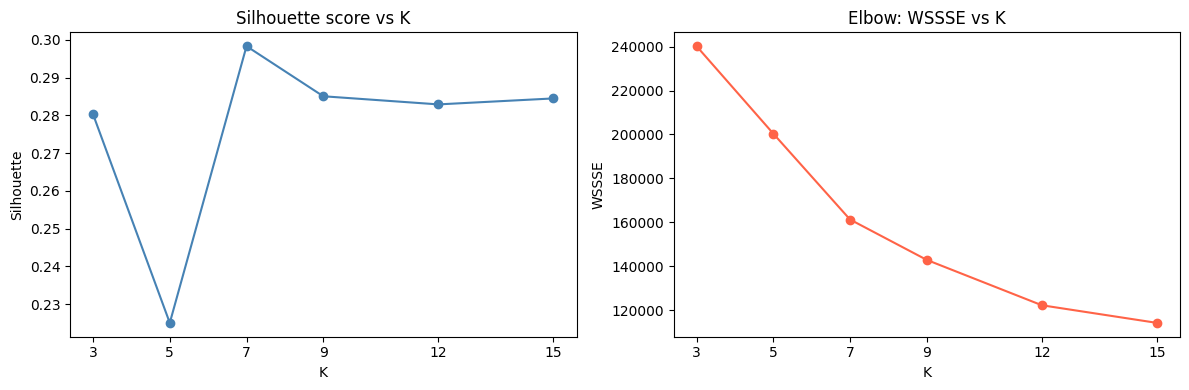

Figura guardada como kmeans_k_selection.png


In [10]:
# Visualización de resultados
import matplotlib.pyplot as plt

ks          = [r["k"]          for r in results]
silhouettes = [r["silhouette"] for r in results]
wssses      = [r["wssse"]      for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, silhouettes, marker="o", color="steelblue")
ax1.set_title("Silhouette score vs K")
ax1.set_xlabel("K"); ax1.set_ylabel("Silhouette")
ax1.set_xticks(ks)

ax2.plot(ks, wssses, marker="o", color="tomato")
ax2.set_title("Elbow: WSSSE vs K")
ax2.set_xlabel("K"); ax2.set_ylabel("WSSSE")
ax2.set_xticks(ks)

plt.tight_layout()
plt.savefig("kmeans_k_selection.png", dpi=120)
plt.show()
print("Figura guardada como kmeans_k_selection.png")

## Modelo final

Se entrena K-Means con el K seleccionado sobre la muestra completa. Ajusta el valor de  según los resultados de la celda anterior. Se escoge 7 como k-optimal ya que obtuvo el merjo sillhoutte score y las mejores en el elbow arriba de 7 no justifica el aumento de complejidad computacional.

In [11]:
# ── Ajustar K_OPTIMAL tras revisar las gráficas ──────────────────────────────
K_OPTIMAL = 7

km_final = KMeans(
    featuresCol="features", predictionCol="cluster",
    k=K_OPTIMAL, seed=SEED, maxIter=50
)

full_pipeline = Pipeline(stages=[assembler, scaler, km_final])
cluster_model = full_pipeline.fit(sample_df)

clustered_df = cluster_model.transform(sample_df)
clustered_df = clustered_df.cache()

# Silhouette final
eval_final = ClusteringEvaluator(
    featuresCol="features", predictionCol="cluster", metricName="silhouette"
)
sil_final = eval_final.evaluate(clustered_df)
print(f"K={K_OPTIMAL}  Silhouette final: {sil_final:.4f}")

K=7  Silhouette final: 0.2984


## Interpretación de clusters

Se calcula el perfil medio de cada cluster para identificar qué tipo de viaje representa.

In [12]:
profile_cols = [
    "trip_distance_m", "trip_duration_min",
    "pickup_hour", "pickup_weekday",
    "pickup_latitude", "pickup_longitude",
    "dropoff_latitude", "dropoff_longitude",
]

profile = (
    clustered_df
    .groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        *[F.round(F.mean(c), 4).alias(f"mean_{c}") for c in profile_cols]
    )
    .orderBy("cluster")
)

profile.show(K_OPTIMAL, truncate=False)

+-------+-----+--------------------+----------------------+----------------+-------------------+--------------------+---------------------+---------------------+----------------------+
|cluster|n    |mean_trip_distance_m|mean_trip_duration_min|mean_pickup_hour|mean_pickup_weekday|mean_pickup_latitude|mean_pickup_longitude|mean_dropoff_latitude|mean_dropoff_longitude|
+-------+-----+--------------------+----------------------+----------------+-------------------+--------------------+---------------------+---------------------+----------------------+
|0      |8767 |2678.1769           |12.0634               |6.5377          |5.6717             |40.7447             |-73.9856             |40.7449              |-73.9823              |
|1      |12336|2511.6388           |11.7755               |12.4293         |1.8957             |40.7465             |-73.9855             |40.7463              |-73.9836              |
|2      |1135 |17666.2198          |37.9788               |14.3656         

In [13]:
# Distribución de tamaño de clusters
(
    clustered_df
    .groupBy("cluster").count()
    .withColumn("pct", F.round(F.col("count") / n_sample * 100, 2))
    .orderBy("cluster")
    .show()
)

+-------+-----+-----+
|cluster|count|  pct|
+-------+-----+-----+
|      0| 8767|17.56|
|      1|12336|24.71|
|      2| 1135| 2.27|
|      3| 1495|  3.0|
|      4|12395|24.83|
|      5| 1709| 3.42|
|      6|12079| 24.2|
+-------+-----+-----+



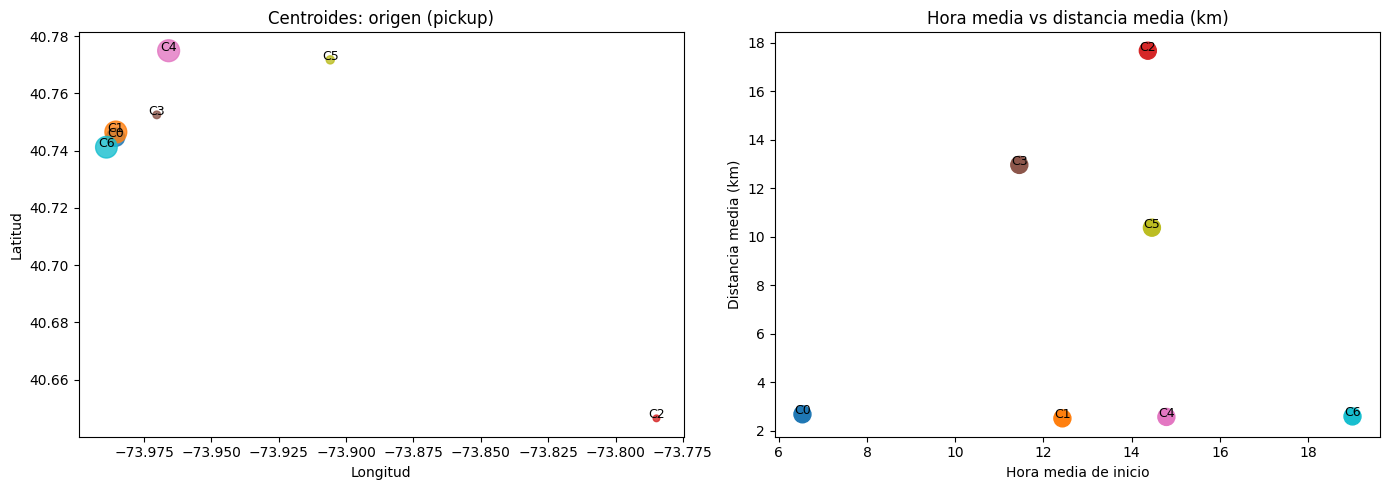

In [14]:
# Scatter plot: origen de cada cluster (pickup_lat vs pickup_lon)
profile_pd = profile.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Centroides en el espacio geográfico de origen
sc1 = axes[0].scatter(
    profile_pd["mean_pickup_longitude"],
    profile_pd["mean_pickup_latitude"],
    c=profile_pd["cluster"], cmap="tab10", s=profile_pd["n"] / 50, alpha=0.8
)
axes[0].set_title("Centroides: origen (pickup)")
axes[0].set_xlabel("Longitud"); axes[0].set_ylabel("Latitud")
for _, row in profile_pd.iterrows():
    axes[0].annotate(f"C{int(row.cluster)}",
                     (row.mean_pickup_longitude, row.mean_pickup_latitude),
                     fontsize=9, ha="center")

# Hora media vs distancia media por cluster
sc2 = axes[1].scatter(
    profile_pd["mean_pickup_hour"],
    profile_pd["mean_trip_distance_m"] / 1000,
    c=profile_pd["cluster"], cmap="tab10", s=150
)
axes[1].set_title("Hora media vs distancia media (km)")
axes[1].set_xlabel("Hora media de inicio"); axes[1].set_ylabel("Distancia media (km)")
for _, row in profile_pd.iterrows():
    axes[1].annotate(f"C{int(row.cluster)}",
                     (row.mean_pickup_hour, row.mean_trip_distance_m / 1000),
                     fontsize=9, ha="center")

plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=120)
plt.show()

In [19]:
import folium
from folium.plugins import MarkerCluster

COLORS = [
    "red", "blue", "green", "purple", "orange",
    "darkred", "darkblue", "darkgreen", "cadetblue", "black"
]

MAP_SAMPLE = 5_000
map_fraction = min(1.0, MAP_SAMPLE / n_sample)

map_pd = (
    clustered_df
    .select("pickup_latitude", "pickup_longitude", "cluster")
    .sample(withReplacement=False, fraction=map_fraction, seed=42)
    .toPandas()
)

nyc_map = folium.Map(location=[40.75, -73.99], zoom_start=11, tiles="CartoDB positron")

for cluster_id in sorted(map_pd["cluster"].unique()):
    cluster_data = map_pd[map_pd["cluster"] == cluster_id]
    color = COLORS[cluster_id % len(COLORS)]

    # FeatureGroup registra el nombre en LayerControl; MarkerCluster solo no lo hace
    fg = folium.FeatureGroup(name=f"Cluster {cluster_id}  (n≈{len(cluster_data):,})", show=True)
    mc = MarkerCluster()
    for _, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=[row["pickup_latitude"], row["pickup_longitude"]],
            radius=3, color=color, fill=True,
            fill_color=color, fill_opacity=0.6,
        ).add_to(mc)
    mc.add_to(fg)
    fg.add_to(nyc_map)

for _, row in profile_pd.iterrows():
    folium.Marker(
        location=[row["mean_pickup_latitude"], row["mean_pickup_longitude"]],
        popup=folium.Popup(
            f"<b>Cluster {int(row.cluster)}</b><br>"
            f"n={int(row.n):,}<br>"
            f"Dist. media: {row.mean_trip_distance_m/1000:.1f} km<br>"
            f"Hora media: {row.mean_pickup_hour:.1f}h",
            max_width=200
        ),
        icon=folium.Icon(color=COLORS[int(row.cluster) % len(COLORS)], icon="info-sign"),
    ).add_to(nyc_map)

folium.LayerControl(collapsed=False).add_to(nyc_map)

nyc_map.save("cluster_map.html")


## Mapa de clusters

In [20]:
nyc_map

## Conclusiones

K-Means sobre los datos de viajes de taxi de NYC revela perfiles de movilidad que no son evidentes en una estratificación manual. A diferencia de las categorías definidas a priori en la actividad anterior (franja horaria × zona geográfica × tipo de día), los clusters emergen de la geometría real de los datos: combinaciones de origen, destino, distancia y hora que coexisten con alta frecuencia.

Los clusters pueden servir como base para una **estratificación más razonada** en trabajos supervisados posteriores. En lugar de definir estratos por criterios externos, se pueden usar las etiquetas de cluster como categorías de muestreo, con la garantía de que cada estrato corresponde a un patrón real de viaje y no a una intersección arbitraria de variables categóricas.

Entre las limitaciones del enfoque:

- K-Means asume clusters convexos y de varianza similar, lo que puede no capturar la forma real de los grupos en un espacio geográfico irregular como NYC.
- La distancia haversine mide distancia en línea recta, no la ruta real en la red vial.
- El número óptimo de clusters depende del criterio de evaluación; Silhouette y WSSSE pueden sugerir valores distintos.

Como extensión, algoritmos como DBSCAN o Gaussian Mixture Models podrían capturar formas de cluster más complejas, a costa de mayor costo computacional en un entorno distribuido.

### Modelos del lenguaje utilizados

- Anthropic. (2026). Claude Sonnet 4.6 [Modelo de lenguaje grande], utilizado para generación de código y formateo en markdown.
- Google. (2026). Gemini Flash 2.5 [Modelo de lenguaje grande], utilizado para generación de código y depuración.